Notebook to test training data generator

To generate full training data sets:

    for level in 0.00 0.05 0.10 0.20 0.40 0.60; 
    do python make_training_data.py --path training_data/d$level --size 500000 --difficulty $level; 
    done



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from make_training_data import make_training_data, PipetteTemplates, NoiseData

In [2]:
#template = PipetteTemplate('yip_2019_template.npz')
template = PipetteTemplates(glob.glob('template_data/template_*.npz'))
# template = PipetteTemplate('template_data/template_002.npz')

noise_data = NoiseData(glob.glob('template_data/background_data/ImageSequence*/image_000.ma'))


In [3]:
training_data = []

levels = [0, 0.05, 0.1, 0.2, 0.4, 0.6]
shape = (20, len(levels))

for j in range(shape[1]):
    training_data.append([])
    difficulty = levels[j]
    for i in range(shape[0]):
        training_data[-1].append(make_training_data(
            difficulty=difficulty, 
            size=400, 
            template=template, 
            noise_data=noise_data,
            # angle_deg_stdev=2,
            # scale_exponent_stdev=0.1,
        ))


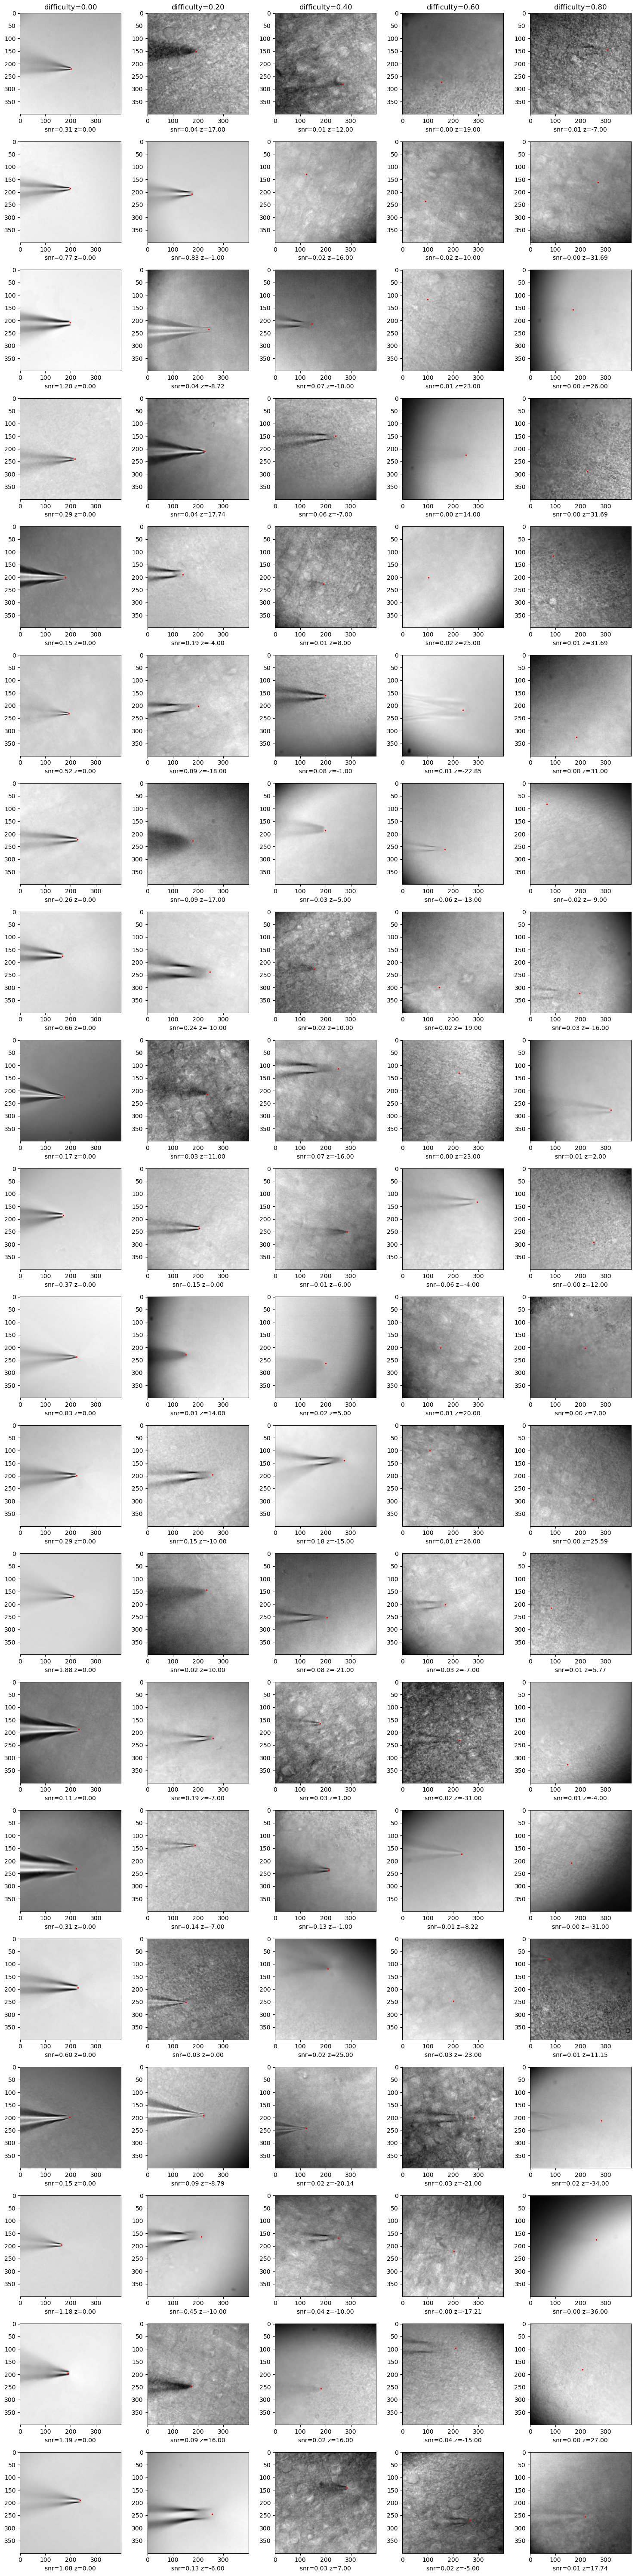

In [6]:
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j in range(shape[1]):
    difficulty = levels[j]
    ax[0,j].set_title(f"difficulty={difficulty:0.2f}")
    for i in range(shape[0]):
        image, pip_pos, image_stats = training_data[j][i]

        # ax[i,j].imshow(mask, cmap='gray')
        ax[i,j].imshow(image, cmap='gray')

        ax[i,j].scatter(pip_pos[2], pip_pos[1], color='red', s=2)
        ax[i,j].set_xlabel(f'snr={image_stats['snr']:0.2f} z={pip_pos[0]:0.2f}')

fig.tight_layout()

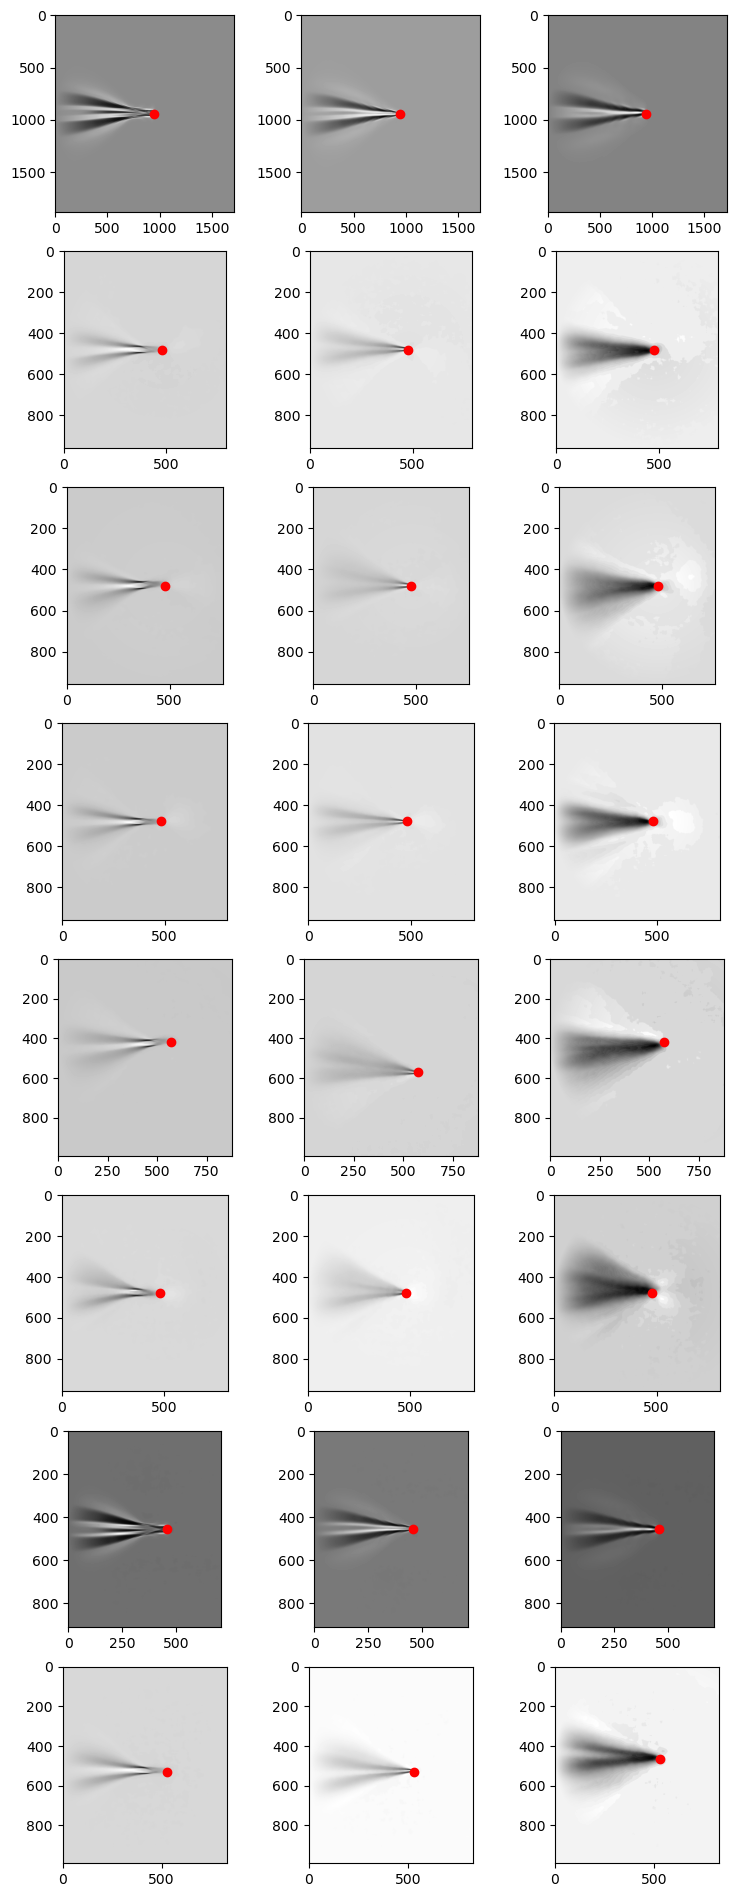

In [7]:
fig, ax = plt.subplots(len(template.templates), 3, figsize=(9, 3*len(template.templates)))

for i,t in enumerate(template.templates):
    for j,z in enumerate([-20, 0, 20]):
        img, pos, px_size = t.get_image(z=z)
        ax[i,j].imshow(img, cmap='gray')
        ax[i,j].scatter(pos[2], pos[1], color='red')
